## Basic Statistics (1–20)

#### **1. What is statistics?**
Statistics is a branch of applied mathematics that involves the collection, organization, analysis, interpretation, and presentation of data. In the context of Data Science and Machine Learning, statistics provides the mathematical foundation required to understand data distributions, quantify uncertainty, and make data-driven decisions.

Statistics is broadly divided into two main branches:

1. **Descriptive Statistics:**  
Focuses on summarizing and organizing the characteristics of a dataset. It provides a quick overview of the data without drawing any broader conclusions.
    * **Measures of Central Tendency:** Mean ($\mu$), Median, Mode.
    * **Measures of Dispersion:** Variance ($\sigma^2$), Standard Deviation ($\sigma$), Range, Interquartile Range (IQR).
    * **Visualization:** Histograms, Box plots, Scatter plots.

2. **Inferential Statistics:**  
Focuses on making predictions, inferences, or generalizations about a larger **population** based on a smaller, representative **sample**.
    * **Techniques:** Hypothesis testing, Confidence Intervals, Regression analysis, Analysis of Variance (ANOVA).
    * **Key Concept:** We calculate a sample statistic (like the sample mean, $\bar{x}$) to estimate a population parameter (like the population mean, $\mu$).


**Interview Takeaway:**  
When an interviewer asks this, they want to see if you understand the difference between just summarizing data (descriptive) and using data to make predictions about the unknown (inferential).

In [1]:
import numpy as np
from scipy import stats

# 1. DATA COLLECTION (Simulating a population of 10,000 users' ages)
np.random.seed(42)
population_ages = np.random.normal(loc=35, scale=10, size=10000)

# ==========================================
# 2. DESCRIPTIVE STATISTICS
# Summarizing our known data (the population)
# ==========================================
print("--- Descriptive Statistics ---")
print(f"Population Mean: {np.mean(population_ages):.2f}")
print(f"Population Std Dev: {np.std(population_ages):.2f}")
print(f"Median Age: {np.median(population_ages):.2f}")

# ==========================================
# 3. INFERENTIAL STATISTICS
# Making predictions about the population using a small sample
# ==========================================
print("\n--- Inferential Statistics ---")
# Taking a random sample of 50 users
sample_ages = np.random.choice(population_ages, size=50, replace=False)
sample_mean = np.mean(sample_ages)
print(f"Sample Mean: {sample_mean:.2f}")

# Hypothesis Testing (1-Sample T-Test)
# Null Hypothesis (H0): The population mean is 30
# Alternative Hypothesis (H1): The population mean is NOT 30
t_stat, p_value = stats.ttest_1samp(sample_ages, popmean=30)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. The population mean is likely NOT 30.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")

--- Descriptive Statistics ---
Population Mean: 34.98
Population Std Dev: 10.03
Median Age: 34.97

--- Inferential Statistics ---
Sample Mean: 35.59
T-statistic: 3.74
P-value: 0.0005
Conclusion: Reject the null hypothesis. The population mean is likely NOT 30.


#### **2. What is the difference between descriptive and inferential statistics?**
The fundamental difference lies in their **purpose** and the **scope of the data** they deal with. Descriptive statistics tells you exactly what is happening in the data you have in front of you. Inferential statistics uses that data to guess what is happening in the data you *don't* have.

Here is a quick comparison table for your notes:

| Feature | Descriptive Statistics | Inferential Statistics |
| --- | --- | --- |
| **Purpose** | To summarize, organize, and describe the characteristics of a known dataset. | To make predictions, generalizations, or conclusions about a larger population. |
| **Scope of Data** | Focuses only on the exact data provided (Sample or Population). | Uses a subset (Sample) to estimate the whole (Population). |
| **Output** | Exact numbers (exact mean, variance, etc.) and visual charts. | Probabilities, confidence intervals, and margins of error. |
| **Key Methods** | Mean, Median, Mode, Variance ($\sigma^2$), Standard Deviation ($\sigma$), Range. | Hypothesis Testing (Z-test, T-test, ANOVA), Confidence Intervals, Regression. |
| **Analogy** | Reviewing the exact grades of 50 students in your class. | Using those 50 grades to predict the school-wide average. |

**The Core Concept: Population vs. Sample**

* **Population (N):** The entire group you want to draw conclusions about.
* **Sample (n):** The specific group you collect data from.
Inferential statistics is the mathematical bridge that allows us to go from $n$ to $N$.

**Interview Takeaway:**
If asked this in an interview, emphasize the concept of **uncertainty**. Descriptive statistics has zero uncertainty (you are just calculating facts about a dataset). Inferential statistics inherently involves uncertainty, which is why we rely on concepts like *p-values* and *confidence intervals* to measure how reliable our guesses are.

In [3]:
import numpy as np
import scipy.stats as st

# Setup: Let's create a hidden 'Population' of 50,000 salaries (e.g., an entire city)
# In reality, we rarely have access to this full data.
np.random.seed(42)
population_salaries = np.random.normal(loc=80000, scale=15000, size=50000)

# We only have access to a sample of 100 people from this city
sample_salaries = np.random.choice(population_salaries, size=100, replace=False)

# ==========================================
# 1. DESCRIPTIVE STATISTICS
# Stating facts about the exact 100 people in our dataset. 
# ==========================================
print("--- Descriptive Statistics (Facts about our Sample) ---")
print(f"Sample Mean Salary: ${np.mean(sample_salaries):,.2f}")
print(f"Sample Max Salary: ${np.max(sample_salaries):,.2f}")
print(f"Sample Std Dev: ${np.std(sample_salaries, ddof=1):,.2f}")
# Notice: There is no guessing here. These are absolute mathematical facts about these 100 people.

# ==========================================
# 2. INFERENTIAL STATISTICS
# Using our 100 people to estimate the salaries of the entire city of 50,000.
# ==========================================
print("\n--- Inferential Statistics (Estimating the Population) ---")
sample_mean = np.mean(sample_salaries)
sample_std_err = st.sem(sample_salaries) # Standard Error of the Mean

# Calculating a 95% Confidence Interval
ci_lower, ci_upper = st.t.interval(
    confidence=0.95, 
    df=len(sample_salaries)-1, 
    loc=sample_mean, 
    scale=sample_std_err
)

print(f"Point Estimate (Best guess for city average): ${sample_mean:,.2f}")
print(f"95% Confidence Interval: [${ci_lower:,.2f} ,${ci_upper:,.2f}]")
print("Interpretation: We are 95% confident that the TRUE average salary of the entire city falls between these two bounds.")

--- Descriptive Statistics (Facts about our Sample) ---
Sample Mean Salary: $82,663.06
Sample Max Salary: $116,970.53
Sample Std Dev: $14,851.67

--- Inferential Statistics (Estimating the Population) ---
Point Estimate (Best guess for city average): $82,663.06
95% Confidence Interval: [$79,716.16 ,$85,609.95]
Interpretation: We are 95% confident that the TRUE average salary of the entire city falls between these two bounds.


#### **3. What is a population?**
In statistics, a **population** represents the entire, complete set of individuals, items, or data points that you are interested in studying or making inferences about. It contains every single member that meets a specific set of criteria.

Because collecting data on an entire population is usually impossible due to time, cost, or physical constraints (e.g., measuring the height of every living human), data scientists typically work with smaller samples to estimate the population's characteristics.

**Population Parameters**  
When you calculate a measurable characteristic of a population, it is called a **parameter**. These are fixed, true values (even if they are unknown to us). We use Greek or uppercase letters to denote them:

* **Population Size:** $N$
* **Population Mean:** $\mu = \frac{\sum_{i=1}^{N} x_i}{N}$
* **Population Variance:** $\sigma^2 = \frac{\sum_{i=1}^{N} (x_i - \mu)^2}{N}$
* **Population Standard Deviation:** $\sigma = \sqrt{\sigma^2}$

**Types of Populations:**  
1. **Finite Population:** A population with a countable number of elements (e.g., all employees currently working at a specific tech company).
2. **Infinite (or extremely large) Population:** A population where counting every element is theoretically impossible (e.g., all the stars in the universe, or all potential future clicks on a website).

**Interview Takeaway:**
If asked to differentiate between population and sample, remember this simple mnemonic rule: **P**opulations have **P**arameters, and **S**amples have **S**tatistics. An interviewer wants to hear that you understand a population represents the "ground truth" that a machine learning model or statistical test is ultimately trying to estimate.

In [4]:
import numpy as np

# ==========================================
# DEFINING THE POPULATION
# Let's assume our population is the exact exam scores 
# of all 5,000 students in a university.
# ==========================================
np.random.seed(101)
# Generating 5000 scores with an average around 75
population_scores = np.random.normal(loc=75, scale=8, size=5000)

# ==========================================
# CALCULATING POPULATION PARAMETERS
# We use ddof=0 (Delta Degrees of Freedom = 0) for populations
# ==========================================
N = len(population_scores)                 # Population Size
mu = np.mean(population_scores)            # Population Mean (μ)
sigma_squared = np.var(population_scores, ddof=0) # Population Variance (σ²)
sigma = np.std(population_scores, ddof=0)  # Population Std Dev (σ)

print("--- Population Parameters (The Ground Truth) ---")
print(f"Population Size (N): {N}")
print(f"Population Mean (μ): {mu:.2f}")
print(f"Population Variance (σ²): {sigma_squared:.2f}")
print(f"Population Standard Deviation (σ): {sigma:.2f}")

# ==========================================
# CONTRASTING WITH A SAMPLE
# ==========================================
# Taking a random sample of 100 students
sample_scores = np.random.choice(population_scores, size=100, replace=False)

# Sample statistics use standard Latin letters and ddof=1 for variance/std
n = len(sample_scores)
x_bar = np.mean(sample_scores)
s = np.std(sample_scores, ddof=1)

print("\n--- Sample Statistics (Our Estimate) ---")
print(f"Sample Size (n): {n}")
print(f"Sample Mean (x̄): {x_bar:.2f} (Estimating μ={mu:.2f})")
print(f"Sample Std Dev (s): {s:.2f} (Estimating σ={sigma:.2f})")

--- Population Parameters (The Ground Truth) ---
Population Size (N): 5000
Population Mean (μ): 75.22
Population Variance (σ²): 67.60
Population Standard Deviation (σ): 8.22

--- Sample Statistics (Our Estimate) ---
Sample Size (n): 100
Sample Mean (x̄): 76.27 (Estimating μ=75.22)
Sample Std Dev (s): 8.06 (Estimating σ=8.22)


#### **4. What is a sample?**
A **sample** is a smaller, manageable subset of individuals, items, or data points drawn from a larger population. Because it is usually impossible, too expensive, or too time-consuming to measure an entire population, data scientists analyze samples to make informed estimates (inferences) about the broader group.

For a sample to be useful, it must be **representative**, meaning it accurately reflects the characteristics of the entire population. This is usually achieved through random sampling.

**Sample Statistics**  
When you calculate a measurable characteristic of a sample, it is called a **statistic**. We use lowercase or Latin letters to denote them:

* **Sample Size:** $n$
* **Sample Mean:** $\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$
* **Sample Variance:** $s^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}$
* **Sample Standard Deviation:** $s = \sqrt{s^2}$

**Interview Takeaway (The "Gotcha"):**
Interviewers love asking why we divide by $n-1$ instead of $n$ when calculating sample variance. Dividing by $n - 1$ is known as **Bessel's correction**. Because a sample doesn't contain the extreme values of the full population, calculating variance by dividing by just $n$ consistently *underestimates* the true population variance. Dividing by $n - 1$ slightly increases the final number, making it an **unbiased estimator** of the population variance.

In [5]:
import numpy as np

# ==========================================
# 1. SETUP: Create a population and draw a sample
# ==========================================
np.random.seed(42)
# Population: Let's say, transaction amounts for 100,000 customers
population_transactions = np.random.normal(loc=150, scale=40, size=100000)

# Sample: We randomly select 50 transactions to analyze
sample_transactions = np.random.choice(population_transactions, size=50, replace=False)

# ==========================================
# 2. CALCULATING SAMPLE STATISTICS
# ==========================================
n = len(sample_transactions)
x_bar = np.mean(sample_transactions)

# CRITICAL: In NumPy, ddof (Delta Degrees of Freedom) defaults to 0. 
# For sample variance/std, you MUST set ddof=1 to apply Bessel's correction (n-1).
# Pandas, conversely, defaults to ddof=1.
s_squared = np.var(sample_transactions, ddof=1) 
s = np.std(sample_transactions, ddof=1)

print("--- Sample Statistics ---")
print(f"Sample Size (n): {n}")
print(f"Sample Mean (x̄): ${x_bar:.2f}")
print(f"Sample Variance (s²): {s_squared:.2f}")
print(f"Sample Standard Deviation (s): ${s:.2f}")

# ==========================================
# 3. INTERVIEW DEMONSTRATION: Why n-1 matters
# ==========================================
print("\n--- The Impact of Bessel's Correction (n-1) ---")
biased_variance = np.var(sample_transactions, ddof=0) # Dividing by n
true_pop_variance = np.var(population_transactions, ddof=0) # The ground truth we are trying to guess

print(f"True Population Variance (Ground Truth): {true_pop_variance:.2f}")
print(f"Biased Sample Variance (Dividing by n):  {biased_variance:.2f} (Underestimates!)")
print(f"Unbiased Sample Variance (Dividing by n-1): {s_squared:.2f} (Better estimate)")

--- Sample Statistics ---
Sample Size (n): 50
Sample Mean (x̄): $152.41
Sample Variance (s²): 1747.30
Sample Standard Deviation (s): $41.80

--- The Impact of Bessel's Correction (n-1) ---
True Population Variance (Ground Truth): 1602.88
Biased Sample Variance (Dividing by n):  1712.35 (Underestimates!)
Unbiased Sample Variance (Dividing by n-1): 1747.30 (Better estimate)


#### **5. What is a parameter?**
In statistics, a **parameter** is a numerical value that describes a characteristic of an entire **population**. You can think of it as the absolute "ground truth" of the group you are studying.

Because populations are usually too large to measure completely, population parameters are almost always **unknown** in real-world data science. Instead, we calculate *statistics* from smaller samples to estimate these true *parameters*.

**Parameters vs. Statistics**  
To keep them straight, remember: **P**opulations have **P**arameters; **S**amples have **S**tatistics.

By convention, statistical parameters are represented by Greek letters, while sample statistics are represented by standard Latin letters.

| Measure | Population Parameter (The Truth) | Sample Statistic (The Estimate) |
| --- | --- | --- |
| **Size** | $N$ | $n$ |
| **Mean** | $\mu$ (Mu) | $\bar{x}$ (x-bar) |
| **Variance** | $\sigma^2$ (Sigma squared) | $s^2$ |
| **Standard Deviation** | $\sigma$ (Sigma) | $s$ |
| **Proportion** | $p$ | $\hat{p}$ (p-hat) |

**Interview Takeaway:**
If an interviewer asks you to define a parameter, emphasize that a parameter is a **fixed but usually unknown constant**. The entire field of inferential statistics and machine learning revolves around building models (using sample data) to accurately estimate these unknown population parameters.

In [7]:
import numpy as np

# ==========================================
# 1. THE UNSEEN POPULATION (The "Ground Truth")
# ==========================================
# Imagine this is the true height (in cm) of every adult male in a country.
# In reality, we never have access to this full array.
np.random.seed(42)
population_heights = np.random.normal(loc=175.5, scale=7.2, size=1000000)

# ==========================================
# 2. CALCULATING THE PARAMETERS
# ==========================================
# If we had god-like access to all the data, we could calculate the exact parameters.
parameter_mu = np.mean(population_heights)
parameter_sigma = np.std(population_heights, ddof=0) 

print("--- True Population Parameters (Usually Unknown) ---")
print(f"Population Mean (μ): {parameter_mu:.3f} cm")
print(f"Population Std Dev (σ): {parameter_sigma:.3f} cm")

# ==========================================
# 3. ESTIMATING PARAMETERS USING STATISTICS
# ==========================================
# Data scientists only get to see a sample (e.g., measuring 500 people).
sample_heights = np.random.choice(population_heights, size=500, replace=False)

statistic_xbar = np.mean(sample_heights)
statistic_s = np.std(sample_heights, ddof=1) # ddof=1 for sample!

print("\n--- Sample Statistics (Our Estimates) ---")
print(f"Sample Mean (x̄): {statistic_xbar:.3f} cm")
print(f"Sample Std Dev (s): {statistic_s:.3f} cm")

# The difference between the statistic and the parameter is the "Sampling Error"
sampling_error = statistic_xbar - parameter_mu
print(f"\nSampling Error (x̄ - μ): {sampling_error:.3f} cm")

--- True Population Parameters (Usually Unknown) ---
Population Mean (μ): 175.488 cm
Population Std Dev (σ): 7.201 cm

--- Sample Statistics (Our Estimates) ---
Sample Mean (x̄): 175.066 cm
Sample Std Dev (s): 7.487 cm

Sampling Error (x̄ - μ): -0.423 cm


#### **6. What is a statistic?**
In statistics, a **statistic** (singular) is a numerical value calculated from a **sample** of data. It is used to summarize the sample and, most importantly, to estimate the corresponding but unknown population parameter.

**The Crucial Difference (Statistic vs. Parameter)**  
While a population parameter is a *fixed, constant value* (e.g., the true average height of everyone on Earth never changes at an exact moment), a statistic is a **random variable**. Because a statistic is based on a random sample, if you draw a new sample, you will get a different statistic.

This variation between different samples is called **sampling variability**.

**Common Statistics Notation (Latin Letters):**
* **Sample Mean:** $\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$
* **Sample Variance:** $s^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}$
* **Sample Standard Deviation:** $s = \sqrt{s^2}$
* **Sample Proportion:** $\hat{p} = \frac{x}{n}$

**Interview Takeaway:**
An interviewer will want to hear that you understand a statistic is not a fixed number—it is a random variable that has its own probability distribution (known as the *sampling distribution*). This is the foundational concept that makes confidence intervals and hypothesis testing possible; because statistics vary, we need to quantify how much they are likely to bounce around the true parameter.

In [6]:
import numpy as np

# ==========================================
# 1. SETUP THE POPULATION
# ==========================================
np.random.seed(42)
# True population of 10,000 house prices
population_prices = np.random.normal(loc=300000, scale=50000, size=10000)

# The Parameter is fixed and constant. 
parameter_mu = np.mean(population_prices)
print(f"Fixed Population Parameter (μ): ${parameter_mu:,.0f}")
print("-" * 45)

# ==========================================
# 2. DEMONSTRATING SAMPLING VARIABILITY
# ==========================================
# We will draw 5 different random samples of 100 houses each.
# Notice how the STATISTIC changes every time, even though 
# they come from the exact same population.

for i in range(1, 6):
    # Draw a new sample
    sample = np.random.choice(population_prices, size=100, replace=False)
    
    # Calculate the sample statistic (x̄)
    statistic_xbar = np.mean(sample)
    
    # Calculate the error (difference between our guess and the truth)
    error = statistic_xbar - parameter_mu
    
    print(f"Sample {i} | Statistic (x̄): ${statistic_xbar:,.0f} | Error: ${error:,.0f}")

# The key lesson: A statistic is not one number; it's a random outcome 
# dependent on which specific data points ended up in your sample.

Fixed Population Parameter (μ): $299,893
---------------------------------------------
Sample 1 | Statistic (x̄): $305,839 | Error: $5,946
Sample 2 | Statistic (x̄): $299,117 | Error: $-777
Sample 3 | Statistic (x̄): $300,593 | Error: $700
Sample 4 | Statistic (x̄): $300,315 | Error: $422
Sample 5 | Statistic (x̄): $306,694 | Error: $6,801


#### **7. What are qualitative and quantitative data?**
At the highest level, data is classified into two main categories based on whether it represents a measurable quantity or a descriptive category. Understanding this distinction is the first step in any exploratory data analysis (EDA) process.

**1. Qualitative Data (Categorical Data)**  
Qualitative data describes qualities, characteristics, or categories. It cannot be quantified with numbers in a mathematically meaningful way (you cannot calculate an average or a variance).

* **Nominal Data:** Categories with no inherent mathematical order or ranking.
* *Examples:* Eye color (Blue, Brown, Green), Car brands, City names.

* **Ordinal Data:** Categories that have a logical, defined order or ranking, but the exact distance between them is not mathematically measurable.
* *Examples:* Education level (High School $\rightarrow$ Bachelor's $\rightarrow$ Master's), Customer satisfaction ratings (Poor $\rightarrow$ Good $\rightarrow$ Excellent).

**2. Quantitative Data (Numerical Data)**  
Quantitative data represents numerical values that can be counted or measured. You can apply mathematical operations (addition, mean, standard deviation) to this data.

* **Discrete Data:** Numerical values that can only take specific, isolated values (usually whole numbers resulting from counting).
* *Examples:* Number of children in a family (you can't have 2.5 children), number of cars in a parking lot.

* **Continuous Data:** Numerical values that can take any value within a given range, including decimals and fractions (usually resulting from measuring).
* *Examples:* Height (175.4 cm), Weight (65.2 kg), Time (12.34 seconds).

**Interview Takeaway:**
Interviewers ask this to see if you know how to treat data before feeding it into a machine learning model. You should mention that this classification determines your preprocessing strategy: **Quantitative** data usually requires scaling or normalization (like Standard Scaling), whereas **Qualitative** data requires encoding techniques (like One-Hot Encoding for nominal data, or Label Encoding for ordinal data).

In [8]:
import pandas as pd

# ==========================================
# 1. CREATING A MIXED DATASET
# ==========================================
data = {
    # QUALITATIVE (Categorical)
    'City': ['Kolkata', 'Bengaluru', 'Kolkata', 'Delhi', 'Bengaluru'],       # Nominal
    'Feedback': ['Good', 'Excellent', 'Average', 'Good', 'Excellent'],       # Ordinal
    
    # QUANTITATIVE (Numerical)
    'Num_Purchases': [3, 1, 0, 5, 2],                                        # Discrete
    'Time_Spent_Mins': [12.5, 45.2, 5.0, 112.3, 22.1]                        # Continuous
}

df = pd.DataFrame(data)

# Best Practice: Explicitly cast ordinal data to a categorical type with order
feedback_order = ['Average', 'Good', 'Excellent']
df['Feedback'] = pd.Categorical(df['Feedback'], categories=feedback_order, ordered=True)

# ==========================================
# 2. INSPECTING DATA TYPES
# ==========================================
print("--- Pandas Data Types ---")
print(df.dtypes)
# Notice: pandas represents strings/nominal data as 'object' 
# Numerical data is represented as 'int64' or 'float64'

# ==========================================
# 3. DIFFERENT ANALYSIS FOR DIFFERENT TYPES
# ==========================================
print("\n--- Analyzing Qualitative Data ---")
# We use value_counts() to get frequencies, because mean() makes no sense here.
print(df['City'].value_counts())

print("\n--- Analyzing Quantitative Data ---")
# We use describe() to get statistical measures (mean, std, min, max)
print(df[['Num_Purchases', 'Time_Spent_Mins']].describe().loc[['mean', 'std']])

--- Pandas Data Types ---
City                 object
Feedback           category
Num_Purchases         int64
Time_Spent_Mins     float64
dtype: object

--- Analyzing Qualitative Data ---
City
Kolkata      2
Bengaluru    2
Delhi        1
Name: count, dtype: int64

--- Analyzing Quantitative Data ---
      Num_Purchases  Time_Spent_Mins
mean       2.200000        39.420000
std        1.923538        43.457761


#### **8. What are discrete and continuous variables?**
Both discrete and continuous variables are sub-categories of **Quantitative (Numerical) Data**, but they fundamentally differ in how they are measured and the mathematical rules that govern them.

**1. Discrete Variables (The "Countables")**  
Discrete variables can only take on specific, distinct, and separate values. There are hard boundaries between values, meaning you cannot have a fraction or decimal between two consecutive valid numbers.

* **Action:** You *count* discrete variables.
* **Examples:** Number of children in a household (you can have 2 or 3, but not 2.4), number of defective items in a batch, number of website clicks.
* **Probability:** Governed by a **Probability Mass Function (PMF)**. You can calculate the probability of an exact, specific outcome, written as $P(X = x)$.
* **Common Distributions:** Binomial, Poisson, Geometric.

**2. Continuous Variables (The "Measurables")**  
Continuous variables can take on an infinite number of possible values within any given range. No matter how close two continuous values are, there is always another possible value between them (limited only by the precision of your measuring instrument).

* **Action:** You *measure* continuous variables.
* **Examples:** Exact height (175.432... cm), weight, temperature, time passed before a server crashes.
* **Probability:** Governed by a **Probability Density Function (PDF)**. The probability of a continuous variable equaling one exact, specific number is technically zero ($P(X = x) = 0$). Instead, you calculate the probability of the variable falling within a *range*, written as $P(a \le X \le b)$.
* **Common Distributions:** Normal, Exponential, Uniform.

**Interview Takeaway:**
When an interviewer asks this, immediately pivot to how this impacts **Exploratory Data Analysis (EDA) and Visualization**. State clearly: "For discrete variables, I would use Bar Charts and look at frequency counts because the values are distinct. For continuous variables, I would use Histograms or KDE (Kernel Density Estimate) plots and look at summary statistics like mean and variance, because we need to group the infinite values into 'bins' to make sense of them."

In [9]:
import numpy as np
import pandas as pd

np.random.seed(42)

# ==========================================
# 1. SIMULATING DISCRETE VARIABLES (Counting)
# ==========================================
# Simulating the number of customer service calls received per hour (Poisson distribution)
discrete_calls = np.random.poisson(lam=3, size=1000)

# ==========================================
# 2. SIMULATING CONTINUOUS VARIABLES (Measuring)
# ==========================================
# Simulating the exact duration of those calls in minutes (Exponential distribution)
continuous_duration = np.random.exponential(scale=5.5, size=1000)

# ==========================================
# 3. PROGRAMMATIC DIFFERENCES IN EDA
# ==========================================
df = pd.DataFrame({
    'Calls_Per_Hour_Discrete': discrete_calls,
    'Call_Duration_Continuous': continuous_duration
})

print("--- Unique Values Check (The 'Count' Test) ---")
# A dataset of 1,000 rows will have very few unique discrete values, 
# but almost every continuous value will be unique.
print(f"Unique discrete values: {df['Calls_Per_Hour_Discrete'].nunique()}")
print(f"Unique continuous values: {df['Call_Duration_Continuous'].nunique()}")

print("\n--- How to Analyze Discrete Variables ---")
# Use value_counts() to see exact frequencies of specific outcomes
print(df['Calls_Per_Hour_Discrete'].value_counts().sort_index().head())

print("\n--- How to Analyze Continuous Variables ---")
# value_counts() is useless for continuous data (every value appears once).
# Instead, we use describe() or bin the data (like a histogram).
print(df['Call_Duration_Continuous'].describe()[['min', 'max', 'mean']])

# Binning continuous data to understand its distribution
print("\nBinned Continuous Data (Top 3 Bins):")
print(pd.cut(df['Call_Duration_Continuous'], bins=5).value_counts().head(3))

--- Unique Values Check (The 'Count' Test) ---
Unique discrete values: 10
Unique continuous values: 1000

--- How to Analyze Discrete Variables ---
Calls_Per_Hour_Discrete
0     50
1    166
2    217
3    226
4    157
Name: count, dtype: int64

--- How to Analyze Continuous Variables ---
min      0.000169
max     33.531045
mean     5.309164
Name: Call_Duration_Continuous, dtype: float64

Binned Continuous Data (Top 3 Bins):
Call_Duration_Continuous
(-0.0334, 6.706]    725
(6.706, 13.413]     195
(13.413, 20.119]     56
Name: count, dtype: int64


#### **9. What are nominal, ordinal, interval, and ratio scales?**
**Levels of Measurement: Nominal, Ordinal, Interval, and Ratio (NOIR):**
The levels of measurement (often called the NOIR scales) dictate what mathematical operations you can legitimately perform on data. This classification tells you exactly what kind of summary statistics and machine learning algorithms are appropriate to use.

Here is the hierarchy, ordered from the least mathematical power to the most:

**1. Nominal Scale (Categories, No Order)**

* **Properties:** Classifies data into mutually exclusive categories. There is no logical or mathematical order.
* **Examples:** Blood type (A, B, AB, O), City of residence, Email provider.
* **Valid Operations:** Counting frequencies, calculating the Mode.
* **Machine Learning:** Requires One-Hot Encoding or Target Encoding.

**2. Ordinal Scale (Categories, Fixed Order)**

* **Properties:** Classifies data into categories that have a clear, logical rank. However, the *distance* or difference between the ranks is unknown or meaningless.
* **Examples:** Customer satisfaction (1 = Bad, 2 = Okay, 3 = Great). Is the difference in happiness between "Bad" and "Okay" exactly equal to the difference between "Okay" and "Great"? We don't know.
* **Valid Operations:** Mode, Median, Percentiles, Rank-order correlation (Spearman).
* **Machine Learning:** Requires Label Encoding or Ordinal Encoding (mapping to integers).

**3. Interval Scale (Numerical, No True Zero)**

* **Properties:** Numerical data where the order matters, and the exact difference (interval) between values is meaningful and equal. However, there is **no true zero** point. A value of "0" doesn't mean the total absence of the thing being measured.
* **Examples:** Temperature in Celsius or Fahrenheit. $0^\circ \text{C}$ doesn't mean "no temperature/no heat" (it's just the freezing point of water). Credit scores (a score of 0 doesn't exist). Year (Year 0 doesn't mean the beginning of time).
* **Valid Operations:** Addition, Subtraction, Mean, Variance, Standard Deviation.
* **Invalid Operations:** Multiplication/Division. (e.g., $40^\circ \text{C}$ is not "twice as hot" as $20^\circ \text{C}$ in terms of thermal energy).

**4. Ratio Scale (Numerical, True Zero)**

* **Properties:** The holy grail of data. It has all the properties of an interval scale, but it **does** have a true, absolute zero. The zero implies the complete absence of the characteristic.
* **Examples:** Salary, Weight, Height, Number of clicks, Distance. $0 means zero money.
* **Valid Operations:** All mathematical operations, including Multiplication and Division (Ratios). Someone earning $100,000 makes exactly twice as much as someone earning $50,000.

**Interview Takeaway:**
The classic interview trap is the difference between Interval and Ratio scales. The interviewer will ask: *"Is temperature in Celsius an interval or ratio variable? What about Kelvin?"*
**Answer:** Celsius is Interval (0 is arbitrary). Kelvin is Ratio (0 Kelvin is absolute zero; no molecular movement). Emphasize that the existence of a "True Zero" is the defining boundary between Interval and Ratio.

#### **10. What are the different types of data?**
In a Data Science interview, this question can be answered from two different perspectives: the **Statistical perspective** (how we measure the data) and the **Structural perspective** (how we store and process the data). A strong candidate will address both.

**1. Statistical Data Types (For Analysis)**  
When performing statistical analysis or preparing features for machine learning, data is divided into quantitative (numbers) and qualitative (categories).

* **Quantitative (Numerical) Data:** Data that can be measured and expressed mathematically.
    * **Discrete:** Countable, distinct values with clear boundaries. (e.g., number of students in a class, number of website clicks).
    * **Continuous:** Measurable values that can take any number within a range, including infinitely small fractions. (e.g., height, weight, time, temperature).

* **Qualitative (Categorical) Data:** Data that describes characteristics, qualities, or categories.
    * **Nominal:** Categories with no inherent mathematical order or ranking. (e.g., eye color, blood type, city of birth).
    * **Ordinal:** Categories with a logical, meaningful order or ranking, but the exact distance between the ranks is unknown. (e.g., education level, customer satisfaction ratings from "Poor" to "Excellent").


**2. Big Data & Storage Types (For Engineering)**  
When building databases, data pipelines, or software architecture, data is categorized by how rigidly it is organized.

* **Structured Data:** Highly organized, easily searchable data formatted in rigid schemas. It typically resides in relational databases (SQL) and is formatted in rows and columns (e.g., Excel spreadsheets, financial transaction records).
* **Unstructured Data:** Data with no predefined format or internal organization, making it much harder to process using traditional databases. (e.g., raw text documents, images, audio files, video).
* **Semi-structured Data:** Data that doesn't fit into a rigid tabular database but does contain tags, markers, or hierarchies to separate semantic elements. (e.g., JSON files, XML, HTML, NoSQL databases).

#### **11. What is frequency distribution?**
A frequency distribution is an organized tabular or graphical summary of a dataset that displays the number of observations (the frequency) that fall into specific distinct categories or mutually exclusive numerical intervals (bins).

It is the foundational tool of Exploratory Data Analysis (EDA), allowing data scientists to quickly understand the shape, spread, and central tendency of a raw, unorganized dataset.

**Key Components:**
1. **Absolute Frequency ($f$):** The raw count of data points in a specific category or interval.
2. **Relative Frequency ($rf$):** The proportion or percentage of the total data points that fall into a category.
* Formula: $rf = \frac{f}{n}$ (where $n$ is the total number of observations).

3. **Cumulative Frequency ($CF$):** The running total of frequencies. It tells you the number of observations that fall *below* the upper limit of a specific interval.
* Formula: $CF_i = f_1 + f_2 + ... + f_i$



**Types of Frequency Distributions:**
* **Categorical Frequency Distribution:** Used for qualitative or discrete data (e.g., counting how many users fall into categories like "Free", "Basic", "Premium"). Visualized using a **Bar Chart**.
* **Grouped Frequency Distribution:** Used for continuous quantitative data. The infinite possible values are grouped into ranges (e.g., ages 10-19, 20-29, 30-39). Visualized using a **Histogram**.

**Interview Takeaway:**
When an interviewer asks about this, connect it directly to data preprocessing. A frequency distribution is how you instantly spot **outliers** (intervals with unexpectedly low counts separated from the main data) and determine the **distribution shape** (e.g., normally distributed, right-skewed, or bimodal), which dictates which machine learning algorithms and statistical tests you can safely apply.

In [10]:
import numpy as np
import pandas as pd

# ==========================================
# 1. SETUP: Generate continuous data (e.g., Customer Ages)
# ==========================================
np.random.seed(42)
ages = np.random.normal(loc=35, scale=10, size=200).astype(int)
df_ages = pd.DataFrame({'Age': ages})

# ==========================================
# 2. CREATING A GROUPED FREQUENCY DISTRIBUTION
# ==========================================
# Step A: Define the intervals (bins)
bins = [10, 20, 30, 40, 50, 60, 70]

# Step B: Group the data into the bins using pd.cut()
df_ages['Age_Group'] = pd.cut(df_ages['Age'], bins=bins, right=False)

# Step C: Calculate Absolute Frequency (f)
freq_dist = df_ages['Age_Group'].value_counts().sort_index().reset_index()
freq_dist.columns = ['Age_Interval', 'Absolute_Frequency (f)']

# Step D: Calculate Relative Frequency (rf)
total_observations = len(df_ages)
freq_dist['Relative_Frequency (rf)'] = freq_dist['Absolute_Frequency (f)'] / total_observations
freq_dist['Relative_Freq_%'] = (freq_dist['Relative_Frequency (rf)'] * 100).round(2).astype(str) + '%'

# Step E: Calculate Cumulative Frequency (CF)
freq_dist['Cumulative_Frequency (CF)'] = freq_dist['Absolute_Frequency (f)'].cumsum()

print("--- Grouped Frequency Distribution Table ---")
print(freq_dist.to_string(index=False))

# ==========================================
# 3. CATEGORICAL FREQUENCY DISTRIBUTION (Quick pandas method)
# ==========================================
# For discrete/categorical data, you can just use value_counts(normalize=True)
subscription_types = np.random.choice(['Free', 'Basic', 'Premium'], size=200, p=[0.5, 0.3, 0.2])
df_subs = pd.Series(subscription_types)

print("\n--- Categorical Frequency Distribution ---")
# Combining absolute and relative frequencies into a single dataframe
cat_freq = pd.DataFrame({
    'Frequency': df_subs.value_counts(),
    'Relative_Freq': df_subs.value_counts(normalize=True).round(2)
})
print(cat_freq)

--- Grouped Frequency Distribution Table ---
Age_Interval  Absolute_Frequency (f)  Relative_Frequency (rf) Relative_Freq_%  Cumulative_Frequency (CF)
    [10, 20)                       9                    0.045            4.5%                          9
    [20, 30)                      53                    0.265           26.5%                         62
    [30, 40)                      87                    0.435           43.5%                        149
    [40, 50)                      38                    0.190           19.0%                        187
    [50, 60)                      11                    0.055            5.5%                        198
    [60, 70)                       1                    0.005            0.5%                        199

--- Categorical Frequency Distribution ---
         Frequency  Relative_Freq
Free            96           0.48
Basic           66           0.33
Premium         38           0.19


#### **12. What is a histogram?**
A histogram is a graphical representation used to visualize the frequency distribution of **continuous quantitative data**. It groups a continuous range of numbers into a set of sequential, equal-sized intervals (called **bins** or buckets) and uses bars to show how many data points fall into each bin.

**Anatomy of a Histogram:**
* **X-axis (Horizontal):** Represents the continuous variable, broken down into intervals (bins). Because the data is continuous, the number line is unbroken.
* **Y-axis (Vertical):** Represents the frequency (count) or relative frequency (percentage) of data points that fall within that specific bin.
* **Area of the Bar:** The height (and area) of each bar is proportional to the frequency of values in that bin.

**Histogram vs. Bar Chart (Crucial Interview Distinction):**  
Interviewers frequently ask to distinguish between the two.
* **Bar charts** plot *categorical* data (like car brands or cities). The bars have **gaps** between them because the categories are separate and distinct.
* **Histograms** plot *continuous* data (like age or salary). There are **no gaps** between the bars (unless a bin naturally has a frequency of 0) because the x-axis represents a continuous, unbroken number line.

**What does a Histogram tell a Data Scientist?**  
During Exploratory Data Analysis (EDA), a histogram is the fastest way to identify:

1. **Central Tendency:** Where is the bulk of the data clustered?
2. **Spread/Variance:** How wide is the range of the data?
3. **Skewness:** Is the data perfectly symmetrical (Normal), pulled to the right (Right-skewed), or pulled to the left (Left-skewed)?
4. **Outliers:** Are there tiny bars separated far away from the main cluster?

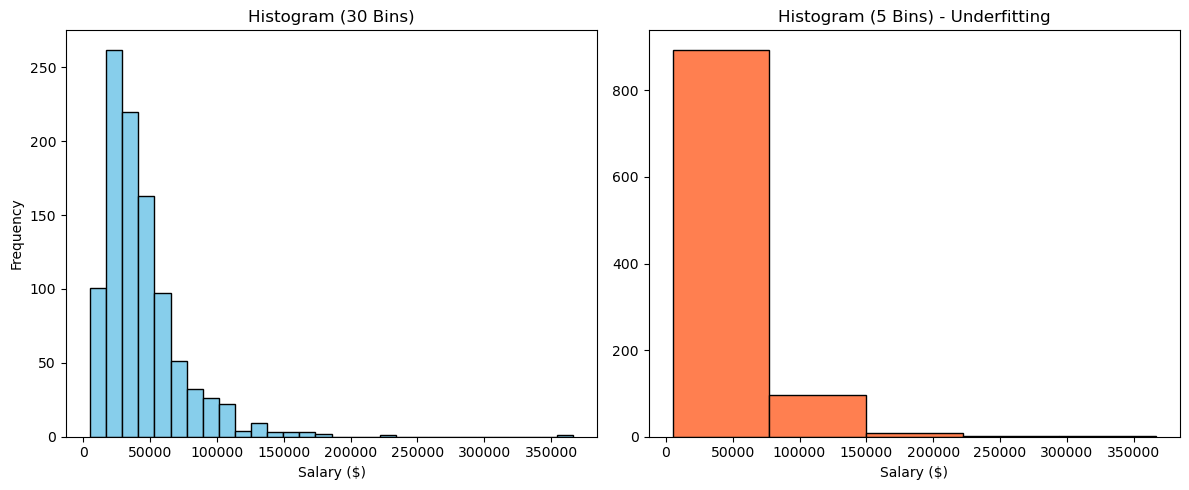

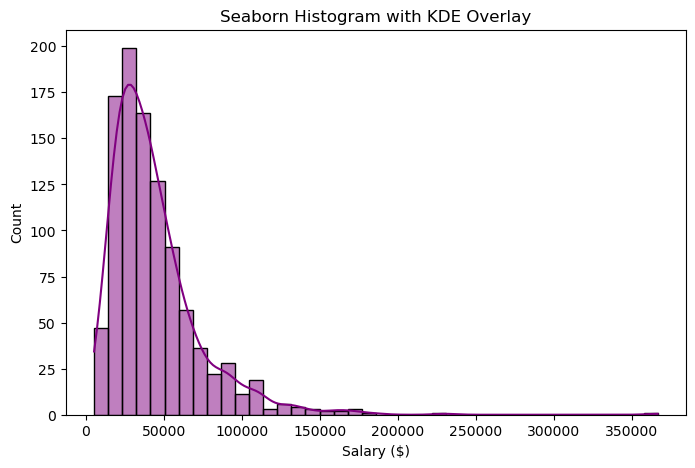

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. GENERATE CONTINUOUS DATA
# ==========================================
np.random.seed(42)
# Generating a dataset representing the salaries of 1000 employees
# Using a log-normal distribution because salaries are typically right-skewed
salaries = np.random.lognormal(mean=10.5, sigma=0.6, size=1000)

# ==========================================
# 2. PLOTTING THE HISTOGRAM (Matplotlib)
# ==========================================
plt.figure(figsize=(12, 5))

# Subplot 1: Histogram with default bins
plt.subplot(1, 2, 1)
plt.hist(salaries, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram (30 Bins)')
plt.xlabel('Salary ($)')
plt.ylabel('Frequency')

# Subplot 2: Histogram with too few bins (hides the shape)
plt.subplot(1, 2, 2)
plt.hist(salaries, bins=5, color='coral', edgecolor='black')
plt.title('Histogram (5 Bins) - Underfitting')
plt.xlabel('Salary ($)')

plt.tight_layout()
plt.show()

# ==========================================
# 3. ADVANCED HISTOGRAM WITH KDE (Seaborn)
# ==========================================
# In modern Data Science, we often overlay a Kernel Density Estimate (KDE) 
# to see the smooth theoretical probability curve on top of the bins.
plt.figure(figsize=(8, 5))
sns.histplot(salaries, bins=40, kde=True, color='purple')
plt.title('Seaborn Histogram with KDE Overlay')
plt.xlabel('Salary ($)')
plt.ylabel('Count')
plt.show()

# Notice how there are NO GAPS between the bars!

#### **13. What is a bar chart?**
A bar chart (or bar graph) is a visual tool used to represent **categorical (qualitative) data** or **discrete quantitative data**. It displays distinct categories as rectangular bars, where the length or height of each bar is directly proportional to the value it represents (such as frequency, count, average, or total).

**Key Characteristics:**
* **Gaps Between Bars:** Unlike a histogram, a standard bar chart has clear spaces between the bars. This visual gap signifies that the categories are distinct, mutually exclusive entities (e.g., "New York" and "London"), not a continuous flowing number line.
* **Orientation:** They can be plotted vertically (often called a column chart) or horizontally. Horizontal bar charts are especially useful when category names are very long.
* **Aggregations:** While histograms strictly show *frequencies* (counts) of data within a bin, a bar chart's y-axis can represent any aggregated metric for that category (e.g., average salary per department, total sales per region, or simple frequency counts).

**Variations:**
1. **Standard Bar Chart:** One variable, one metric.
2. **Grouped (Clustered) Bar Chart:** Compares multiple sub-categories side-by-side (e.g., Sales by Region, split by Year).
3. **Stacked Bar Chart:** Shows the total size of a category, broken down into sub-components stacked on top of each other.

**Interview Takeaway (The Histogram Comparison):**
If an interviewer asks you to compare a bar chart and a histogram, focus on the **data type**. Say: *"A bar chart is for categorical or discrete data, and the bars have gaps to show the categories are distinct. A histogram is for continuous numerical data, and the bars touch to represent a continuous number line."*

/var/folders/tl/hdrnf2y12_dfs7brk68x42yc0000gn/T/ipykernel_55999/1502888992.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_Salary_USD', y='Department', data=df, palette='viridis')


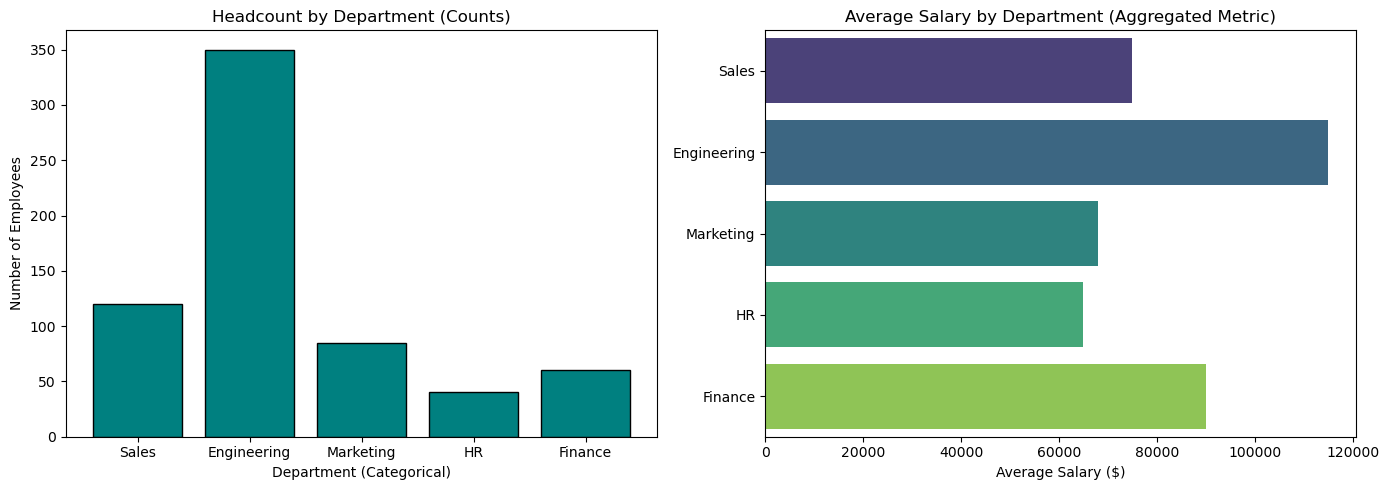

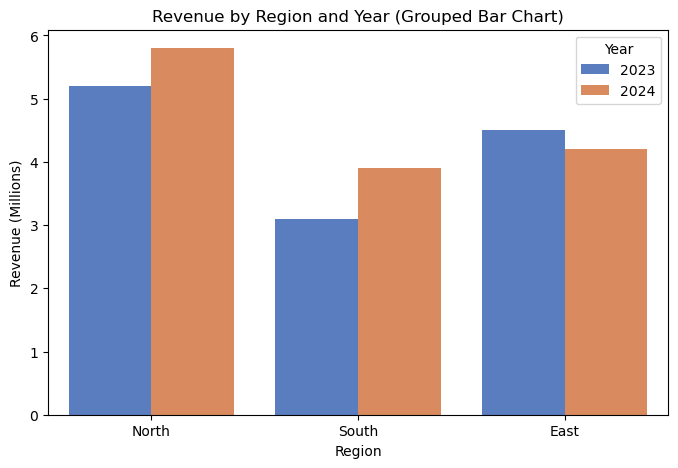

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP: Create Categorical Data
# ==========================================
data = {
    'Department': ['Sales', 'Engineering', 'Marketing', 'HR', 'Finance'],
    'Employee_Count': [120, 350, 85, 40, 60],
    'Avg_Salary_USD': [75000, 115000, 68000, 65000, 90000]
}
df = pd.DataFrame(data)

# ==========================================
# 2. STANDARD VERTICAL BAR CHART (Matplotlib)
# Representing exact counts per category
# ==========================================
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# Notice the spaces between the bars!
plt.bar(df['Department'], df['Employee_Count'], color='teal', edgecolor='black')
plt.title('Headcount by Department (Counts)')
plt.xlabel('Department (Categorical)')
plt.ylabel('Number of Employees')

# ==========================================
# 3. HORIZONTAL BAR CHART (Seaborn)
# Representing an aggregated metric (Average)
# ==========================================
plt.subplot(1, 2, 2)
# Horizontal is great for readability, especially with long category names
sns.barplot(x='Avg_Salary_USD', y='Department', data=df, palette='viridis')
plt.title('Average Salary by Department (Aggregated Metric)')
plt.xlabel('Average Salary ($)')
plt.ylabel('') # Y-label is obvious from category names

plt.tight_layout()
plt.show()

# ==========================================
# 4. GROUPED BAR CHART (Seaborn)
# Comparing multiple variables across categories
# ==========================================
# Creating some multi-year data
df_multi = pd.DataFrame({
    'Region': ['North', 'North', 'South', 'South', 'East', 'East'],
    'Year': ['2023', '2024', '2023', '2024', '2023', '2024'],
    'Revenue': [5.2, 5.8, 3.1, 3.9, 4.5, 4.2]
})

plt.figure(figsize=(8, 5))
# The 'hue' parameter creates the grouped bars
sns.barplot(x='Region', y='Revenue', hue='Year', data=df_multi, palette='muted')
plt.title('Revenue by Region and Year (Grouped Bar Chart)')
plt.ylabel('Revenue (Millions)')
plt.show()

#### **14. What is a box plot?**
A box plot (or box-and-whisker plot) is a standardized way of displaying the distribution of data based on a **five-number summary**. It is one of the most powerful tools in Exploratory Data Analysis (EDA) because it allows you to instantly identify the central tendency, spread, skewness, and exact mathematical outliers of a dataset.

**The Five-Number Summary:**

1. **Minimum:** The lowest data point *excluding* any outliers.
2. **First Quartile ($Q1$):** The 25th percentile. 25% of the data falls below this line. This forms the left/bottom edge of the box.
3. **Median ($Q2$):** The 50th percentile. The middle value of the dataset. This is the line inside the box.
4. **Third Quartile ($Q3$):** The 75th percentile. 75% of the data falls below this line. This forms the right/top edge of the box.
5. **Maximum:** The highest data point *excluding* any outliers.

**The Math Behind the Plot:**
* **Interquartile Range (IQR):** The distance between the first and third quartiles. It represents the middle 50% of the data, where the core bulk of your observations lie.
$$IQR = Q3 - Q1$$

* **Whiskers & Outliers:** The "whiskers" extend from the box to show the range of the non-outlier data. Data points are mathematically classified as **outliers** (and plotted as individual dots) if they fall outside these bounds:
* **Lower Bound:** $Q1 - 1.5 \times IQR$
* **Upper Bound:** $Q3 + 1.5 \times IQR$

**Interview Takeaway (Box Plot vs. Histogram):**
If asked when to use which, explain that **Histograms** are best for looking at the detailed *shape* of a single distribution (e.g., finding out if data is bimodal). **Box plots** are superior when you need to compare multiple distributions side-by-side across different categories (e.g., Salary distributions across 5 different departments) because histograms would overlap and become unreadable.

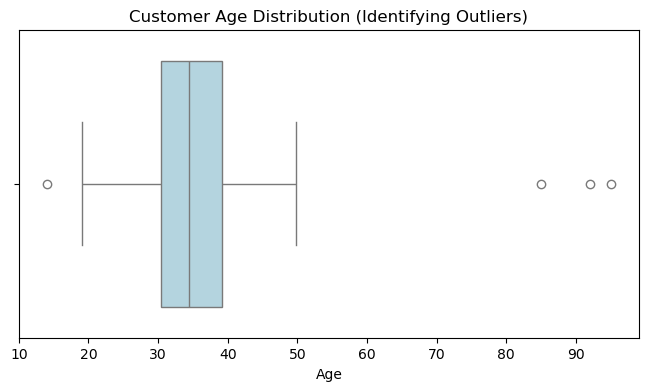

--- The 5-Number Summary & Outlier Math ---
Q1 (25th Percentile): 30.35
Median (50th Percentile): 34.42
Q3 (75th Percentile): 39.22
IQR: 8.88
------------------------------
Lower Outlier Bound: 17.04
Upper Outlier Bound: 52.54

Identified Outliers:
[14.04203917 85.         92.         95.        ]


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP: Create data with intentional outliers
# ==========================================
np.random.seed(42)
# Create a normal distribution of ages
base_ages = np.random.normal(loc=35, scale=8, size=100)
# Inject some extreme outliers (e.g., very old customers)
outliers = np.array([85, 92, 95]) 
ages = np.concatenate([base_ages, outliers])

df = pd.DataFrame({'Customer_Age': ages})

# ==========================================
# 2. PLOTTING THE BOX PLOT (Seaborn)
# ==========================================
plt.figure(figsize=(8, 4))
# Orienting horizontally for easier reading of the x-axis
sns.boxplot(x=df['Customer_Age'], color='lightblue')
plt.title('Customer Age Distribution (Identifying Outliers)')
plt.xlabel('Age')
plt.show()

# ==========================================
# 3. CALCULATING THE MATH BEHIND THE PLOT
# ==========================================
print("--- The 5-Number Summary & Outlier Math ---")

# Calculate Quartiles
Q1 = np.percentile(ages, 25)
Q2 = np.median(ages) # Same as np.percentile(ages, 50)
Q3 = np.percentile(ages, 75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate Whiskers (Outlier Bounds)
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"Q1 (25th Percentile): {Q1:.2f}")
print(f"Median (50th Percentile): {Q2:.2f}")
print(f"Q3 (75th Percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print("-" * 30)
print(f"Lower Outlier Bound: {lower_bound:.2f}")
print(f"Upper Outlier Bound: {upper_bound:.2f}")

# Mathematically filter and find the exact outliers
actual_outliers = df[(df['Customer_Age'] < lower_bound) | (df['Customer_Age'] > upper_bound)]
print(f"\nIdentified Outliers:\n{actual_outliers.values.flatten()}")

#### **15. What is a scatter plot?**
A scatter plot is a two-dimensional data visualization that uses dots to represent the values obtained for two different **continuous quantitative variables** (one plotted along the x-axis and the other along the y-axis).

It is the primary visual tool used in Exploratory Data Analysis (EDA) to determine if a **relationship or correlation** exists between two variables.

**What to Look For in a Scatter Plot:**
When analyzing a scatter plot, data scientists look for three main characteristics:

1. **Direction:**
    * *Positive Correlation:* As $x$ increases, $y$ increases (e.g., Years of Experience vs. Salary). The points trend upward from left to right.
    * *Negative Correlation:* As $x$ increases, $y$ decreases (e.g., Car Weight vs. Fuel Efficiency). The points trend downward.
    * *No Correlation:* The points are scattered randomly like a cloud. Changes in $x$ have no bearing on $y$.

2. **Form:** Is the relationship linear (forms a straight line) or non-linear (forms a curve or U-shape)?
3. **Strength:** How tightly clustered are the points around an imaginary line? Tighter clustering means a stronger mathematical correlation (often measured mathematically by the Pearson Correlation Coefficient, $r$).

**Interview Takeaway (Scatter Plot vs. Line Chart):**
A common interview trap is confusing when to use a scatter plot versus a line chart.

* Use a **Line Chart** when your x-axis has a sequential, inherent order (like time: days, months, years) to show a trend over time.
* Use a **Scatter Plot** when your data points are independent of one another (e.g., plotting the height and weight of 100 different, independent people) to find correlations.

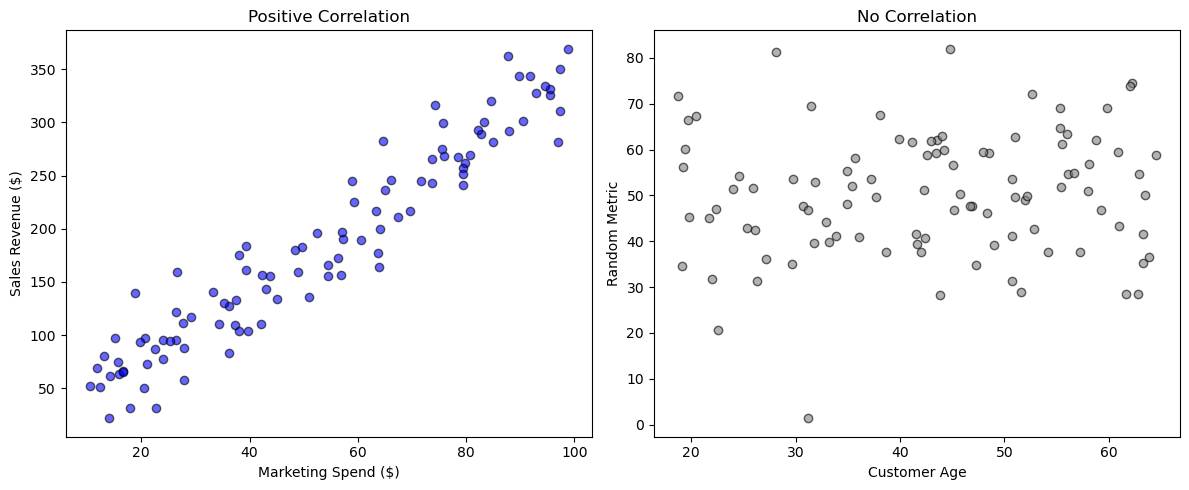

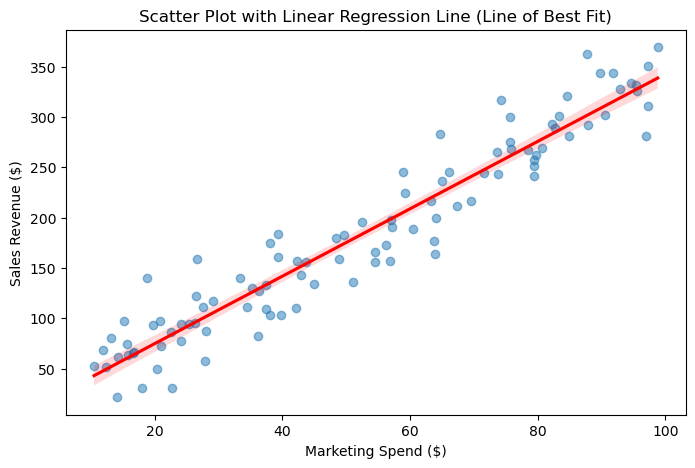

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. GENERATE BIVARIATE DATA (Pairs of X and Y)
# ==========================================
np.random.seed(42)

# Case 1: Positive Correlation (e.g., Marketing Spend vs. Sales)
x_spend = np.random.uniform(10, 100, 100)
# y is dependent on x, plus some random noise
y_sales = (3.5 * x_spend) + np.random.normal(0, 30, 100) 

# Case 2: No Correlation (e.g., Customer Age vs. Random ID number)
x_age = np.random.uniform(18, 65, 100)
y_random = np.random.normal(50, 15, 100)

# ==========================================
# 2. PLOTTING SCATTER PLOTS (Matplotlib)
# ==========================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# plt.scatter is the standard function
plt.scatter(x_spend, y_sales, color='blue', alpha=0.6, edgecolor='black')
plt.title('Positive Correlation')
plt.xlabel('Marketing Spend ($)')
plt.ylabel('Sales Revenue ($)')

plt.subplot(1, 2, 2)
plt.scatter(x_age, y_random, color='gray', alpha=0.6, edgecolor='black')
plt.title('No Correlation')
plt.xlabel('Customer Age')
plt.ylabel('Random Metric')

plt.tight_layout()
plt.show()

# ==========================================
# 3. ADVANCED SCATTER PLOT WITH REGRESSION (Seaborn)
# ==========================================
# In Machine Learning, we often want to see the "line of best fit" 
# directly on the scatter plot to visualize simple linear regression.
plt.figure(figsize=(8, 5))
# sns.regplot automatically plots the scatter points AND fits a regression line
sns.regplot(x=x_spend, y=y_sales, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Scatter Plot with Linear Regression Line (Line of Best Fit)')
plt.xlabel('Marketing Spend ($)')
plt.ylabel('Sales Revenue ($)')
plt.show()

#### **16. What is a stem-and-leaf plot?**
A stem-and-leaf plot is a technique for displaying quantitative data in a tabular format. It is unique because it visualizes the shape of a frequency distribution (much like a histogram) while **retaining the exact original data points**.

To create it, each number in the dataset is divided into two parts:

* **The Stem:** The leading digit (or digits).
* **The Leaf:** The final digit.

For example, for the number `42`, the stem is `4` and the leaf is `2`. For `105`, the stem is `10` and the leaf is `5`.

**How to Read It:**  
If you look at a stem-and-leaf plot and turn your head 90 degrees to the right, it looks exactly like a histogram! The "stems" act as the bins (e.g., the 20s, the 30s, the 40s), and the length of the "leaves" represents the frequency of data in that bin.

**Pros and Cons:**  
* **Advantage:** Unlike a histogram, which groups data into opaque bins (e.g., "5 people are between 20-30"), a stem-and-leaf plot shows you exactly what those 5 numbers are (e.g., 21, 22, 25, 28, 29).
* **Disadvantage:** It is absolutely useless for large datasets. It only works well for small datasets (typically under 100 observations).

**Interview Takeaway:**
In a modern Data Science interview, this might be asked as a trivia question to test your fundamental statistics knowledge. If asked to compare it to a histogram, state clearly: *"A histogram loses the individual data points to show the overall shape of large data. A stem-and-leaf plot shows the shape but keeps the exact raw numbers, making it only viable for very small datasets."*

In [16]:
from collections import defaultdict
import numpy as np

# ==========================================
# 1. CREATE A SMALL DATASET
# ==========================================
# Imagine these are the test scores of 25 students in a class
scores = [
    45, 55, 62, 65, 67, 71, 71, 72, 75, 78, 
    79, 81, 83, 85, 85, 88, 90, 92, 92, 94, 
    95, 98, 99, 100, 100
]

# ==========================================
# 2. CUSTOM STEM-AND-LEAF FUNCTION
# (Standard plotting libraries don't include this because 
# it is a text-based visualization)
# ==========================================
def generate_stem_and_leaf(data):
    print("Stem | Leaves")
    print("-----|------------------------")
    
    # Sort data to ensure leaves appear in ascending order
    sorted_data = sorted(data)
    
    # Use a dictionary to group leaves by their stem
    plot_dict = defaultdict(list)
    
    for number in sorted_data:
        # Integer division by 10 gets the stem (e.g., 85 // 10 = 8)
        stem = number // 10
        # Modulo 10 gets the leaf (e.g., 85 % 10 = 5)
        leaf = number % 10
        
        plot_dict[stem].append(str(leaf))
        
    # Print the grouped data
    for stem, leaves in plot_dict.items():
        # Format: pad the stem for alignment, join leaves with a space
        print(f"{stem:>4} | {' '.join(leaves)}")

# ==========================================
# 3. DISPLAY THE PLOT
# ==========================================
generate_stem_and_leaf(scores)

# Notice how the '7', '8', and '9' stems have the longest rows of leaves.
# If you tilt your head right, you can see the data is slightly left-skewed!

Stem | Leaves
-----|------------------------
   4 | 5
   5 | 5
   6 | 2 5 7
   7 | 1 1 2 5 8 9
   8 | 1 3 5 5 8
   9 | 0 2 2 4 5 8 9
  10 | 0 0


#### **17. What is data visualization in statistics?**
Data visualization is the graphical representation of information and data. By using visual elements like charts, graphs, and maps, it provides an accessible way to see and understand trends, outliers, and patterns in data.

In statistics and Data Science, it is the crucial bridge between **Exploratory Data Analysis (EDA)** and human cognition. While descriptive statistics (like mean or standard deviation) summarize data into single numbers, visualization reveals the *shape* and true nature of the data that those numbers might hide.

**Why We Visualize (The Objectives):**
1. **Identify Distributions:** Seeing the shape of the data (e.g., normal, skewed, bimodal) to determine which statistical tests are valid.
2. **Spot Outliers:** Visually catching anomalies (like a typo making a salary $10,000,000 instead of $100,000) before they ruin a machine learning model.
3. **Find Correlations:** Quickly seeing if two variables move together (using scatter plots) before running complex correlation math.
4. **Storytelling:** Communicating complex statistical findings to non-technical stakeholders in a digestible way.

**The Classic Example: Anscombe's Quartet**
If an interviewer asks *why* visualization is necessary, always mention **Anscombe's Quartet**. It is a famous statistical concept consisting of four different datasets that have the exact same summary statistics (same mean, same variance, same correlation). However, when you visualize them, they look completely different. It proves that relying on numbers alone is dangerous.

--- Summary Statistics for the 4 Datasets ---
           x          y      
        mean   var mean   var
dataset                      
I        9.0  11.0  7.5  4.13
II       9.0  11.0  7.5  4.13
III      9.0  11.0  7.5  4.12
IV       9.0  11.0  7.5  4.12


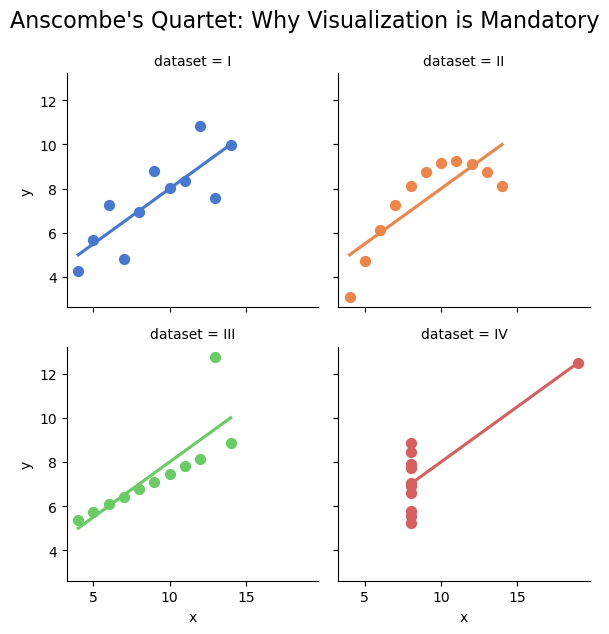

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD ANSCOMBE'S QUARTET
# (The ultimate proof of why visualization matters)
# ==========================================
# Seaborn has this famous dataset built-in!
anscombe = sns.load_dataset("anscombe")

# Let's prove the summary statistics are identical
print("--- Summary Statistics for the 4 Datasets ---")
stats = anscombe.groupby('dataset').agg(['mean', 'var']).round(2)
print(stats)
# Notice how the mean and variance for X and Y are identical across I, II, III, and IV!

# ==========================================
# 2. VISUALIZE THE QUARTET
# ==========================================
# Even though the math says these 4 datasets are the "same", 
# the visualization tells a completely different story.

# lmplot creates a scatter plot with a linear regression line
sns.lmplot(
    data=anscombe, x="x", y="y", col="dataset", hue="dataset", 
    col_wrap=2, ci=None, palette="muted", height=3,
    scatter_kws={"s": 50, "alpha": 1}
)

plt.suptitle("Anscombe's Quartet: Why Visualization is Mandatory", y=1.05, fontsize=16)
plt.show()

# Interpretation of the visual:
# Dataset I: Normal linear relationship.
# Dataset II: Non-linear (curved) relationship. A simple line is the wrong model here.
# Dataset III: A perfect line ruined by a single extreme outlier.
# Dataset IV: No correlation at all, just one extreme outlier forcing the math to look linear.

#### **18. Why is data cleaning important before statistical analysis?**
In statistics and machine learning, there is a golden rule: **Garbage In, Garbage Out (GIGO)**. No matter how sophisticated your statistical model or machine learning algorithm is, if you feed it flawed data, it will output flawed conclusions.

Statistical tests and models make strict assumptions about the underlying data. If those assumptions are violated by "dirty" data, your analysis becomes invalid.

**Key Reasons for Data Cleaning:**
1. **Handling Missing Values (Nulls):** Most statistical algorithms (like regression or PCA) and Python libraries (like Scikit-Learn) will instantly crash if they encounter missing values. Furthermore, ignoring missing data can introduce severe bias if the data is not missing completely at random.
2. **Treating Outliers:** Descriptive statistics, particularly the **mean** and **variance**, are highly sensitive to extreme outliers. A single data entry error (e.g., inputting an age of 300 instead of 30) can drastically shift the mean, tricking you into making incorrect business decisions.
3. **Fixing Inconsistent Formatting:** Categorical data often suffers from human entry error (e.g., "NY", "N.Y.", and "New York"). If not standardized, a frequency distribution will treat these as three separate categories, hiding the true weight of the category.
4. **Removing Duplicates:** Duplicate rows artificially inflate frequency counts and can falsely strengthen the perceived correlation between two variables.
5. **Data Type Correction:** Numbers stored as strings cannot be mathematically aggregated. You cannot calculate the standard deviation of "100".

**Interview Takeaway:**
If asked about this, emphasize that **models are blindly obedient**. A statistical formula doesn't know what an age or a salary is—it just crunches the numbers it is given. It is the Data Scientist's job to ensure those numbers accurately represent reality *before* applying the math. Mention that data cleaning typically takes up 70-80% of a data professional's time.

In [18]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CREATE A "DIRTY" DATASET
# ==========================================
dirty_data = {
    'Employee_ID': [1, 2, 3, 4, 5, 6, 3], # Notice ID 3 is a duplicate
    'Age': [25, 32, 28, 250, 45, np.nan, 28], # Typo: Age 250. Missing: NaN
    'Salary_USD': ['50000', '65000', '58000', '72000', '90000', '60000', '58000'], # Stored as strings
    'Department': ['Sales', 'sales ', 'Marketing', 'HR', 'IT', 'IT', 'Marketing'] # Inconsistent casing/spaces
}

df = pd.DataFrame(dirty_data)

print("--- 1. Attempting Analysis on DIRTY Data ---")
# If we try to get the mean age, the outlier ruins it.
# If we try to get the mean salary, the code will crash or concatenate strings!
print(f"Mean Age (Skewed by outlier): {df['Age'].mean():.2f}")
try:
    print(df['Salary_USD'].mean())
except Exception as e:
    print(f"Error calculating Salary mean: {e}")

# ==========================================
# 2. THE DATA CLEANING PROCESS
# ==========================================
# Step A: Drop duplicates
df_clean = df.drop_duplicates(subset='Employee_ID')

# Step B: Fix Data Types (Convert String to Integer)
df_clean['Salary_USD'] = df_clean['Salary_USD'].astype(int)

# Step C: Handle Missing Values (Impute age with median)
# We use median because it is robust against the outlier currently in the data
median_age = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(median_age)

# Step D: Handle Outliers (Filter out impossible ages)
df_clean = df_clean[df_clean['Age'] < 100]

# Step E: Standardize Categorical Text
df_clean['Department'] = df_clean['Department'].str.strip().str.title()

# ==========================================
# 3. ANALYSIS ON CLEAN DATA
# ==========================================
print("\n--- 2. Analysis on CLEAN Data ---")
print(f"True Mean Age: {df_clean['Age'].mean():.2f}")
print(f"True Mean Salary: ${df_clean['Salary_USD'].mean():,.2f}")
print("\nAccurate Department Frequencies:")
print(df_clean['Department'].value_counts())

--- 1. Attempting Analysis on DIRTY Data ---
Mean Age (Skewed by outlier): 68.00
Error calculating Salary mean: Could not convert string '50000650005800072000900006000058000' to numeric

--- 2. Analysis on CLEAN Data ---
True Mean Age: 32.40
True Mean Salary: $64,600.00

Accurate Department Frequencies:
Department
Sales        2
It           2
Marketing    1
Name: count, dtype: int64


/var/folders/tl/hdrnf2y12_dfs7brk68x42yc0000gn/T/ipykernel_55999/1796633897.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Salary_USD'] = df_clean['Salary_USD'].astype(int)
/var/folders/tl/hdrnf2y12_dfs7brk68x42yc0000gn/T/ipykernel_55999/1796633897.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Age'] = df_clean['Age'].fillna(median_age)


#### **19. What are outliers?**
An outlier is a data point that differs significantly from the rest of the observations in a dataset. It is an anomaly that lies an abnormal distance away from the primary cluster of data.

**Outliers can occur for several reasons:**
1. **Measurement/Entry Error:** Human error (e.g., typing an age of "300" instead of "30") or a broken sensor. These should usually be removed or corrected.
2. **True Anomalies:** Rare but genuine events (e.g., a legitimate $10 million bank transfer in a dataset where the average is $500). These are often the most important data points in specific fields like fraud detection.


**Why Outliers Matter (The Impact)**  
Outliers disproportionately affect sensitive statistical measures.
* They heavily skew the **Mean** and **Variance**, making them unreliable representations of the central tendency and spread.
* However, the **Median** and **Interquartile Range (IQR)** are considered *robust* statistics because they are highly resistant to outliers.

**The Two Primary Methods for Detection:**
1. **The Z-Score Method (Parametric):**
Best used when the data follows a roughly normal distribution. A Z-score tells you how many standard deviations a data point is from the mean.
    * **Formula:** $Z = \frac{X - \mu}{\sigma}$
    * **Rule:** Any data point with a Z-score greater than 3 or less than -3 is typically flagged as an outlier (meaning it falls outside 99.7% of the expected data).

2. **The IQR Method (Non-Parametric):**
Best used for skewed data. This is the mathematical logic used to draw the "whiskers" on a Box Plot.
    * **IQR Formula:** $IQR = Q3 - Q1$
    * **Lower Bound:** $Q1 - (1.5 \times IQR)$
    * **Upper Bound:** $Q3 + (1.5 \times IQR)$
    * **Rule:** Any data point falling outside these bounds is an outlier.

**Interview Takeaway:**
Never say "I would delete all outliers." An interviewer wants to hear that you investigate *why* an outlier exists. Deleting bad data (like an age of 300) is standard, but deleting a true anomaly just to make a model look cleaner is bad data science. Mention that instead of deleting, you might **cap** outliers (Winsorization) or use **tree-based ML models** (like Random Forest), which are naturally resistant to them.

In [19]:
import numpy as np
import pandas as pd
from scipy import stats

# ==========================================
# 1. SETUP: Create data with injected outliers
# ==========================================
np.random.seed(42)
# 100 normal transactions averaging $50
normal_data = np.random.normal(loc=50, scale=10, size=100)
# 3 extreme outlier transactions
outliers = np.array([5, 450, 600]) 

# Combine into a single pandas Series
transactions = pd.Series(np.concatenate([normal_data, outliers]))

print("--- Impact on Statistics ---")
print(f"Mean with outliers: ${transactions.mean():.2f} (Heavily Skewed!)")
print(f"Median with outliers: ${transactions.median():.2f} (Robust)")

# ==========================================
# 2. DETECTION METHOD A: Z-SCORE
# ==========================================
print("\n--- 1. Z-Score Detection ---")
# Calculate the absolute Z-score for every row
z_scores = np.abs(stats.zscore(transactions))

# Define the threshold (typically 3 standard deviations)
threshold_z = 3
z_outliers = transactions[z_scores > threshold_z]

print(f"Outliers detected (Z > 3):")
print(z_outliers.values)


# ==========================================
# 3. DETECTION METHOD B: IQR (Box Plot Math)
# ==========================================
print("\n--- 2. IQR Detection ---")
Q1 = transactions.quantile(0.25)
Q3 = transactions.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Filter for data outside the bounds
iqr_outliers = transactions[(transactions < lower_bound) | (transactions > upper_bound)]

print(f"Lower Bound: ${lower_bound:.2f} | Upper Bound: ${upper_bound:.2f}")
print("Outliers detected (outside bounds):")
print(iqr_outliers.values)

# Note: In this specific example, the IQR method caught the low outlier ($5), 
# while the Z-score method missed it because the mean was pulled so high by the 600.

--- Impact on Statistics ---
Mean with outliers: $57.78 (Heavily Skewed!)
Median with outliers: $48.84 (Robust)

--- 1. Z-Score Detection ---
Outliers detected (Z > 3):
[450. 600.]

--- 2. IQR Detection ---
Lower Bound: $27.40 | Upper Bound: $71.64
Outliers detected (outside bounds):
[ 23.80254896   5.         450.         600.        ]


#### **20. How do you detect outliers?**
Detecting outliers depends on the dimensionality of your data (single variable vs. multiple variables) and its underlying distribution. In a data science workflow, outlier detection is typically approached in three ways: Visual, Statistical (Univariate), and Algorithmic (Multivariate).

**1. Visual Detection (Exploratory Phase)**
Before applying mathematical formulas, visualize the data to understand the nature of the outliers.

* **Box Plots:** Instantly highlights values outside the Interquartile Range (IQR). Best for univariate data.
* **Histograms:** Shows isolated bars detached from the main distribution.
* **Scatter Plots:** Best for identifying **multivariate outliers** (e.g., a person who is 6 feet tall and weighs 100 lbs; neither value is an outlier on its own, but the *combination* is anomalous).

**2. Statistical Methods (Univariate Data)**  
Used when analyzing a single feature independently.

* **Z-Score (Parametric):** Measures how many standard deviations a data point is from the mean. Best used when the data follows a Normal (Gaussian) distribution.
* Formula: $Z = \frac{x - \mu}{\sigma}$
* Rule: Flag points where $\vert{}Z\vert{} > 3$.

* **IQR Method (Non-Parametric):** Uses percentiles to find the middle 50% of data. Best used when the data is skewed, because it doesn't rely on the mean.
* Formula: $IQR = Q3 - Q1$
* Rule: Flag points outside $[Q1 - 1.5(IQR), Q3 + 1.5(IQR)]$.


**3. Algorithmic / Machine Learning Methods (Multivariate Data)**  
Used when analyzing complex datasets with multiple features interacting with each other.
* **Isolation Forest:** A tree-based machine learning algorithm that isolates anomalies rather than profiling normal data points. Outliers are easier to isolate, meaning they end up closer to the root of the tree.
* **DBSCAN (Density-Based Spatial Clustering):** A clustering algorithm that groups densely packed points together and flags points that lie alone in low-density regions as "noise" (outliers).

**Interview Takeaway:**
If asked this in an interview, do not just list the formulas. Frame your answer chronologically: *"I always start visually with Box Plots and Scatter Plots to understand the data's shape. If the data is normally distributed and univariate, I apply a Z-score threshold. If it's skewed, I prefer the IQR method. However, for high-dimensional machine learning datasets, I rely on algorithms like Isolation Forest to catch complex, multivariate anomalies."*

In [20]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import IsolationForest

# ==========================================
# 1. SETUP: Create a 2D Dataset with Outliers
# ==========================================
np.random.seed(42)

# Generate normal cluster of data (e.g., Height and Weight)
normal_data = np.random.multivariate_normal(mean=[170, 70], cov=[[50, 40], [40, 50]], size=200)

# Inject specific outliers
# Outlier 1: Univariate Outlier (Extremely heavy)
# Outlier 2: Multivariate Outlier (Tall but extremely light - breaks correlation)
outliers = np.array([[170, 150], [195, 45]]) 

data = np.vstack([normal_data, outliers])
df = pd.DataFrame(data, columns=['Height_cm', 'Weight_kg'])

# ==========================================
# 2. STATISTICAL METHOD: Z-SCORE (Univariate)
# ==========================================
print("--- 1. Z-Score Detection (Univariate on Weight) ---")
# Calculating Z-scores for the Weight column only
df['Weight_ZScore'] = np.abs(stats.zscore(df['Weight_kg']))
z_outliers = df[df['Weight_ZScore'] > 3]

# Notice how Z-score ONLY catches the person weighing 150kg. 
# It misses the 45kg person because 45kg alone isn't a statistical anomaly.
print(z_outliers[['Height_cm', 'Weight_kg', 'Weight_ZScore']])


# ==========================================
# 3. ALGORITHMIC METHOD: ISOLATION FOREST (Multivariate)
# ==========================================
print("\n--- 2. Isolation Forest (Multivariate ML) ---")
# Isolation Forest looks at BOTH features simultaneously
iso_forest = IsolationForest(contamination=0.02, random_state=42) # Expecting ~2% outliers

# Fit and predict (-1 indicates an outlier, 1 is an inlier)
df['Anomaly_Score'] = iso_forest.fit_predict(df[['Height_cm', 'Weight_kg']])

# Filter for the detected anomalies
ml_outliers = df[df['Anomaly_Score'] == -1]

# Notice how Isolation Forest catches BOTH the extreme weight outlier 
# AND the multivariate outlier (the tall/light person) because it analyzes relationships.
print(ml_outliers[['Height_cm', 'Weight_kg', 'Anomaly_Score']])

--- 1. Z-Score Detection (Univariate on Weight) ---
     Height_cm  Weight_kg  Weight_ZScore
200      170.0      150.0       8.869923

--- 2. Isolation Forest (Multivariate ML) ---
      Height_cm   Weight_kg  Anomaly_Score
37   185.735955   89.411614             -1
110  158.648130   50.297466             -1
131  194.033683   89.452482             -1
200  170.000000  150.000000             -1
201  195.000000   45.000000             -1


## Measures of Central Tendency (21–35)

#### **21. What is the mean?**


#### **22. What is the median?**


#### **23. What is the mode?**


#### **24. When should you use the mean?**


#### **25. When should you use the median?**


#### **26. When should you use the mode?**


#### **27. What are the advantages and disadvantages of the mean?**


#### **28. How do outliers affect the mean?**


#### **29. How do outliers affect the median?**


#### **30. What is a weighted mean?**


#### **31. What is a geometric mean?**


#### **32. What is a harmonic mean?**


#### **33. What is a trimmed mean?**


#### **34. What is a moving average?**


#### **35. How do you choose the appropriate measure of central tendency?**


## Measures of Dispersion (36–50)

#### **36. What is range?**


#### **37. What is variance?**


#### **38. What is standard deviation?**


#### **39. What is the difference between variance and standard deviation?**


#### **40. What is the interquartile range (IQR)?**


#### **41. What are quartiles?**


#### **42. What are percentiles?**


#### **43. What are deciles?**


#### **44. What is the coefficient of variation?**


#### **45. What is mean absolute deviation (MAD)?**


#### **46. What is standard error?**


#### **47. What is sampling variability?**


#### **48. Why is standard deviation important?**


#### **49. What is the relationship between variance and standard deviation?**


#### **50. When should you use IQR instead of standard deviation?**


## Distribution & Shape of Data (51–65)

#### **51. What is a statistical distribution?**


#### **52. What is a normal distribution?**


#### **53. What are the properties of a normal distribution?**


#### **54. What is a standard normal distribution?**


#### **55. What is a z-score?**


#### **56. What is skewness?**


#### **57. What is positive skewness?**


#### **58. What is negative skewness?**


#### **59. What is kurtosis?**


#### **60. What are leptokurtic, mesokurtic, and platykurtic distributions?**


#### **61. What is the empirical (68–95–99.7) rule?**


#### **62. What is the difference between symmetric and asymmetric distributions?**


#### **63. What is a bimodal distribution?**


#### **64. What is a multimodal distribution?**


#### **65. How do you determine whether data is normally distributed?**


## Correlation & Covariance (66–75)

#### **66. What is covariance?**


#### **67. What is correlation?**


#### **68. What is the difference between covariance and correlation?**


#### **69. What is Pearson correlation?**


#### **70. What is Spearman rank correlation?**


#### **71. What is Kendall rank correlation?**


#### **72. What does a correlation coefficient of +1, 0, and -1 indicate?**


#### **73. Can correlation imply causation?**


#### **74. What is multicollinearity?**


#### **75. How do you detect multicollinearity?**


## Sampling & Estimation (76–85)

#### **76. What is random sampling?**


#### **77. What are the different sampling methods?**


#### **78. What is stratified sampling?**


#### **79. What is cluster sampling?**


#### **80. What is systematic sampling?**


#### **81. What is sampling bias?**


#### **82. What is sampling error?**


#### **83. What is a point estimate?**


#### **84. What is a confidence interval?**


#### **85. How do sample size and confidence level affect a confidence interval?**


## Hypothesis Testing (86–100)

#### **86. What is hypothesis testing?**


#### **87. What is the null hypothesis?**


#### **88. What is the alternative hypothesis?**


#### **89. What is a significance level (α)?**


#### **90. What is a p-value?**


#### **91. What is a Type I error?**


#### **92. What is a Type II error?**


#### **93. What is statistical power?**


#### **94. What is a one-tailed test?**


#### **95. What is a two-tailed test?**


#### **96. What is a z-test?**


#### **97. What is a t-test?**


#### **98. What is the difference between a z-test and a t-test?**


#### **99. What is ANOVA, and when is it used?**


#### **100. What is the chi-square test, and when is it appropriate?**


## Practical Statistics Questions

#### **101. Calculate the mean, median, mode, variance, and standard deviation of a dataset.**


#### **102. Detect outliers using the IQR method and z-scores.**


#### **103. Determine whether a dataset is normally distributed.**


#### **104. Compute and interpret the correlation between two variables.**


#### **105. Compare two sample means using an appropriate statistical test.**


#### **106. Build and interpret a 95% confidence interval.**


#### **107. Perform a hypothesis test and explain the result.**


#### **108. Decide whether to use a parametric or non-parametric test for a given dataset.**


#### **109. Explain the impact of outliers on descriptive statistics.**


#### **110. Recommend the right statistical test for different business scenarios.**
